# Exploratory Data Analysis (EDA)



Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")
sns.set_context("notebook")


Load Dataset

In [3]:
matches = pd.read_csv("../data/raw/ipl_matches_data.csv")
balls = pd.read_csv("../data/raw/ball_by_ball_data.csv")

print("Matches shape:", matches.shape)
print("Ball-by-ball shape:", balls.shape)


Matches shape: (1169, 23)
Ball-by-ball shape: (278205, 30)


Basic Inception

In [4]:
matches.head()
balls.head()

,season_id,match_id,batter,bowler,non_striker,team_batting,team_bowling,over_number,ball_number,batter_runs,...,is_bye,is_penalty,wide_ball_runs,no_ball_runs,leg_bye_runs,bye_runs,penalty_runs,wicket_kind,is_super_over,innings
0,2008,335982,SC Ganguly,P Kumar,BB McCullum,6,1,0,0,0,...,False,False,0,0,1,0,0,NaN,False,1
1,2008,335982,BB McCullum,P Kumar,SC Ganguly,6,1,0,1,0,...,False,False,0,0,0,0,0,NaN,False,1
2,2008,335982,BB McCullum,P Kumar,SC Ganguly,6,1,0,2,0,...,False,False,1,0,0,0,0,NaN,False,1
3,2008,335982,BB McCullum,P Kumar,SC Ganguly,6,1,0,3,0,...,False,False,0,0,0,0,0,NaN,False,1
4,2008,335982,BB McCullum,P Kumar,SC Ganguly,6,1,0,4,0,...,False,False,0,0,0,0,0,NaN,False,1


Schema and Data Types

In [5]:
matches.info()
balls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1169 entries, 0 to 1168
Data columns (total 23 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   match_id         1169 non-null   int64  
 1   season_id        1169 non-null   int64  
 2   balls_per_over   1169 non-null   int64  
 3   city             1118 non-null   object 
 4   match_date       1169 non-null   object 
 5   event_name       1169 non-null   object 
 6   match_number     1099 non-null   float64
 7   gender           1169 non-null   object 
 8   match_type       1169 non-null   object 
 9   format           1169 non-null   object 
 10  overs            1169 non-null   int64  
 11  season           1169 non-null   object 
 12  team_type        1169 non-null   object 
 13  venue            1169 non-null   object 
 14  toss_winner      1169 non-null   int64  
 15  team1            1169 non-null   int64  
 16  team2            1169 non-null   int64  
 17  toss_decision 

Missing Value Analysis

In [6]:
matches.isnull().sum().sort_values(ascending=False)
balls.isnull().sum().sort_values(ascending=False)

fielders_involved    264382
player_out           264382
wicket_kind          264382
batter                    0
season_id                 0
match_id                  0
team_bowling              0
over_number               0
ball_number               0
batter_runs               0
extras                    0
bowler                    0
non_striker               0
team_batting              0
bowler_type               0
batsman_type              0
total_runs                0
is_wicket                 0
is_no_ball                0
is_leg_bye                0
is_bye                    0
is_wide_ball              0
is_penalty                0
wide_ball_runs            0
leg_bye_runs              0
no_ball_runs              0
bye_runs                  0
penalty_runs              0
is_super_over             0
innings                   0
dtype: int64

Checking Duplicates

In [7]:
print("Duplicate rows in matches:", matches.duplicated().sum())
print("Duplicate rows in balls:", balls.duplicated().sum())


Duplicate rows in matches: 0
Duplicate rows in balls: 0


Distribution of Batsman Runs per Ball

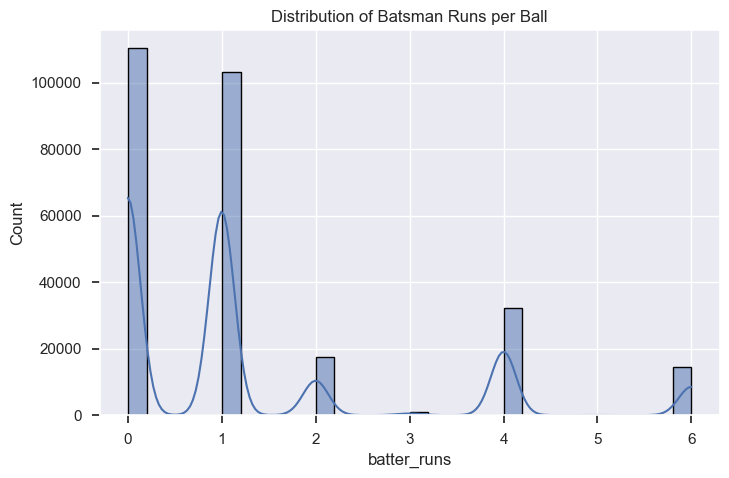

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(balls['batter_runs'], bins=30, kde=True)
plt.title("Distribution of Batsman Runs per Ball")
plt.show()


Total Runs per Match

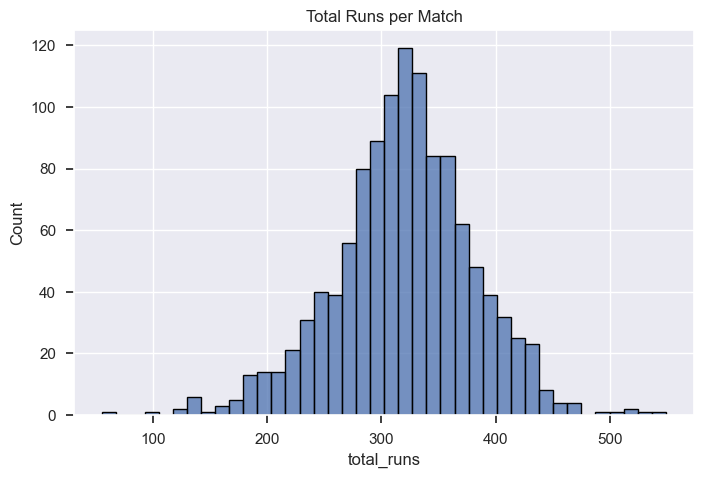

In [11]:
match_runs = balls.groupby('match_id')['total_runs'].sum()

plt.figure(figsize=(8,5))
sns.histplot(match_runs, bins=40)
plt.title("Total Runs per Match")
plt.show()


Top Batsmen by Total Runs

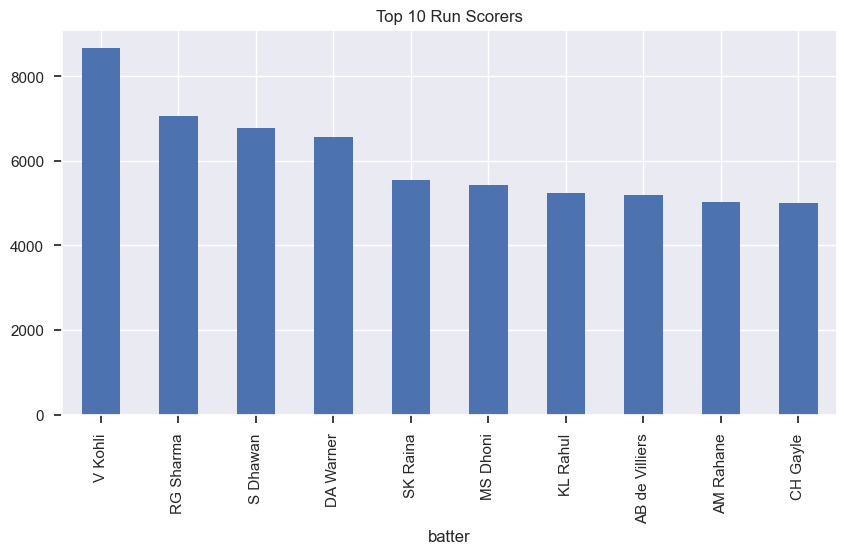

In [13]:
top_batsmen = (
    balls.groupby('batter')['batter_runs']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_batsmen.plot(kind='bar', figsize=(10,5), title="Top 10 Run Scorers")
plt.show()


Wicket Distribution

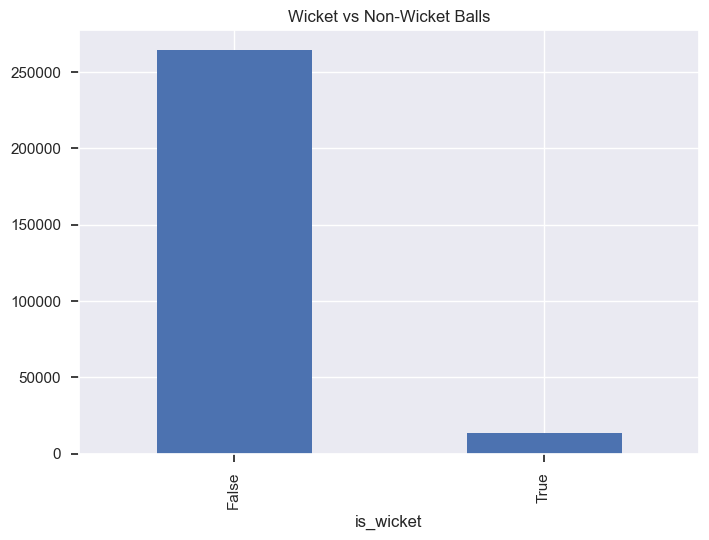

In [14]:
dismissals = balls['is_wicket'].value_counts()

dismissals.plot(kind='bar', title="Wicket vs Non-Wicket Balls")
plt.show()


Venue Analysis

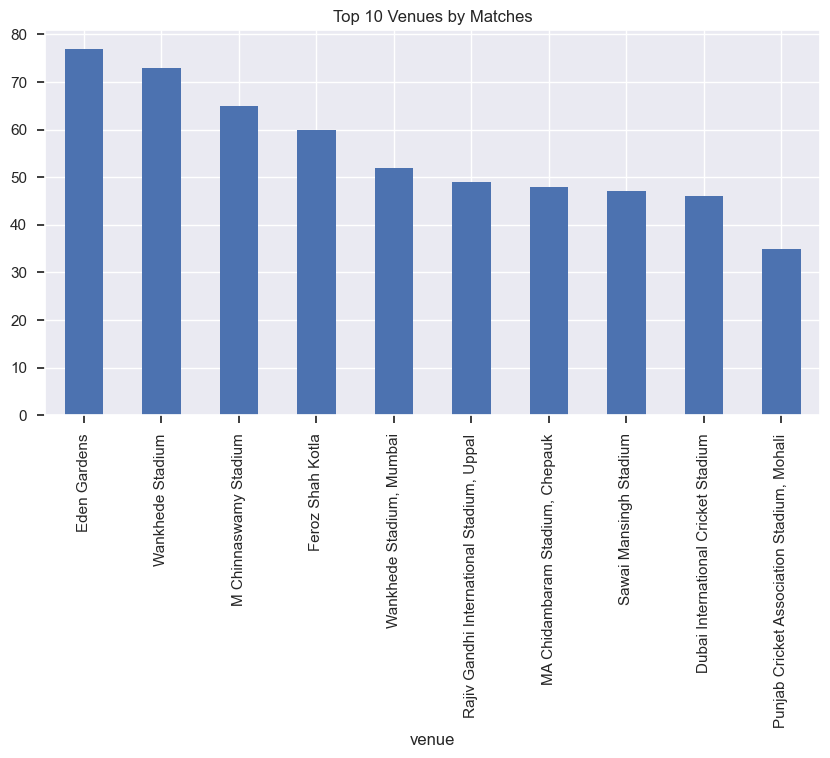

In [15]:
venue_matches = matches['venue'].value_counts().head(10)

venue_matches.plot(kind='bar', figsize=(10,5), title="Top 10 Venues by Matches")
plt.show()


## Notebook Summary
- Imported core data/visualization libraries and set unified seaborn styling for all plots.
- Loaded raw IPL matches plus ball-by-ball datasets, verified shapes, schema details, and basic samples.
- Audited data quality via null counts, dtypes, and duplicate checks to spot cleanup needs early.
- Visualized batter-level scoring patterns, per-match run totals, wicket distributions, and venue frequencies.
- Highlighted top run scorers to surface standout players for downstream modeling or storytelling.